In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:



class Reward_manager:
    """
    Reward Manager for Continuous Control
    ------------------------------------
    - Uses FIFO (circular buffer) with pointer
    - Supports realistic initialization (reset)
    - Designed for real-world continuous control & RL
    """

    def __init__(self, buffer_size=5):
        self.buffer_size = buffer_size

        # FIFO buffers
        self.setpoint_buffer = np.zeros(buffer_size)
        self.state_buffer    = np.zeros(buffer_size)
        self.error_buffer    = np.zeros(buffer_size)
        self.action_buffer   = np.zeros(buffer_size)

        # Reward weights
        self.w_error = 1.0
        self.w_smooth = 0.1
        self.w_stability = 0.5

        # Pointer & counter
        self.ptr = 0
        self.count = 0

    # --------------------------------------------------
    # Initialization (important for real systems)
    # --------------------------------------------------
    def reset(self, init_setpoint, init_state, init_action):
        """
        Initialize FIFO buffers with realistic initial conditions.
        Prevents artificial reward spikes at the beginning.
        """
        init_error = init_setpoint - init_state

        self.setpoint_buffer[:] = init_setpoint
        self.state_buffer[:]    = init_state
        self.error_buffer[:]    = init_error
        self.action_buffer[:]   = init_action

        self.ptr = 0
        self.count = self.buffer_size

    # --------------------------------------------------
    # Update FIFO buffers
    # --------------------------------------------------
    def update(self, setpoint, state, action):
        error = setpoint - state

        self.setpoint_buffer[self.ptr] = setpoint
        self.state_buffer[self.ptr]    = state
        self.error_buffer[self.ptr]    = error
        self.action_buffer[self.ptr]   = action

        self.ptr = (self.ptr + 1) % self.buffer_size
        self.count = min(self.count + 1, self.buffer_size)

    # --------------------------------------------------
    # Helper functions
    # --------------------------------------------------
    def previous_action(self):
        if self.count < 2:
            return 0.0
        idx = (self.ptr - 2) % self.buffer_size
        return self.action_buffer[idx]

    def delta_error(self):
        if self.count < 2:
            return 0.0

        idx_now  = (self.ptr - 1) % self.buffer_size
        idx_prev = (self.ptr - 2) % self.buffer_size

        return self.error_buffer[idx_now] - self.error_buffer[idx_prev]

    # --------------------------------------------------
    # Reward function
    # --------------------------------------------------
    def reward_continuous_control(self):
        if self.count < 2:
            return 0.0

        e_now  = self.error_buffer[(self.ptr - 1) % self.buffer_size]
        a_now  = self.action_buffer[(self.ptr - 1) % self.buffer_size]
        a_prev = self.action_buffer[(self.ptr - 2) % self.buffer_size]

        # 1) Tracking error
        r_error = -abs(e_now)

        # 2) Smoothness of control action
        r_smooth = -abs(a_now - a_prev)

        # 3) Stability (error derivative)
        r_stability = -abs(self.delta_error())

        reward = (
            self.w_error     * r_error +
            self.w_smooth    * r_smooth +
            self.w_stability * r_stability
        )

        return reward


In [10]:
def simple_system(state, action, alpha=0.2):
    """
    First-order system:
    x_{t+1} = x_t + alpha (u_t - x_t)
    """
    return state + alpha * (action - state)


In [11]:
T = 100
setpoint = 1.0

state = 0.0
action = 0
reward_manager = Reward_manager(buffer_size=5)

states  = []
actions = []
rewards = []
errors  = []


In [12]:
Kp = 1.2
reward_manager.reset(
    init_setpoint=setpoint,
    init_state=state,
    init_action=0
)
for t in range(T):
    error = setpoint - state
    action = Kp * error   # controller ธรรมดา
    
    # update reward manager
    reward_manager.update(setpoint, state, action)
    reward = reward_manager.reward_continuous_control()
    
    # simulate system
    state = simple_system(state, action)
    
    # log
    states.append(state)
    actions.append(action)
    rewards.append(reward)
    errors.append(error)


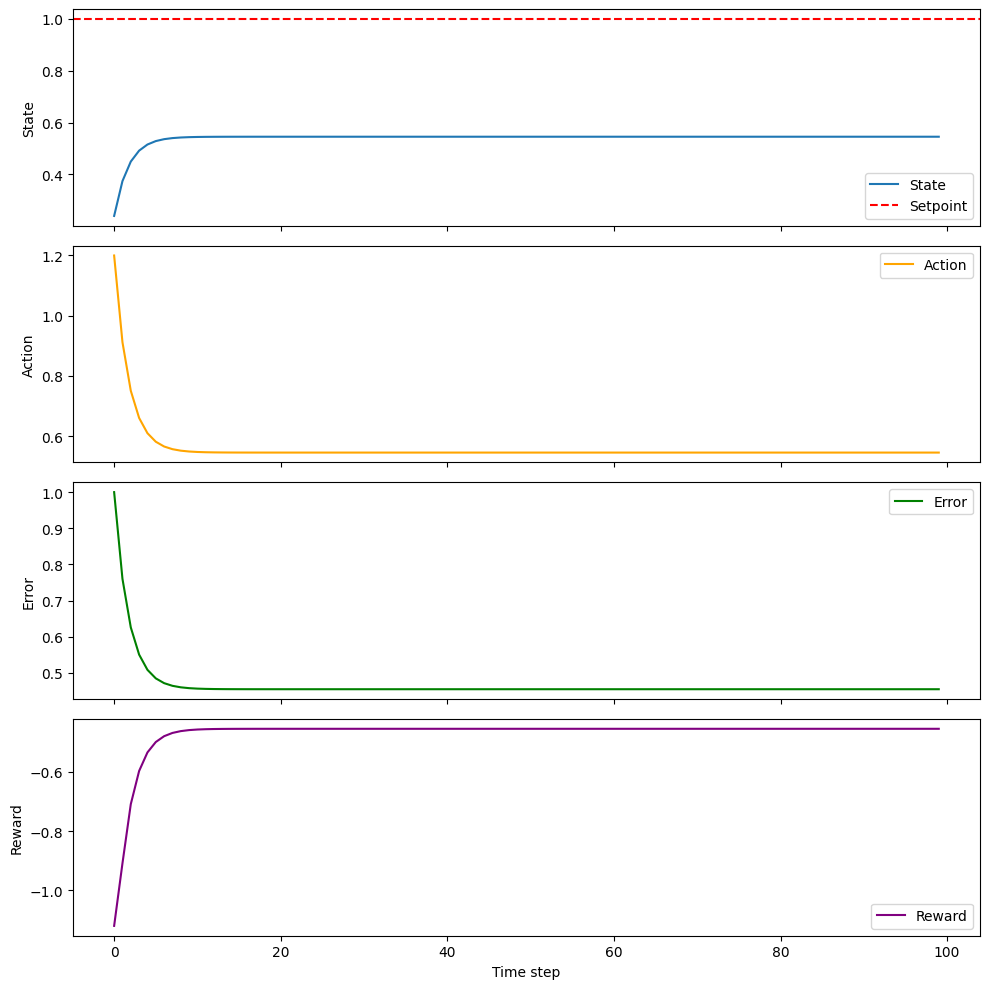

In [13]:
fig, axs = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

axs[0].plot(states, label="State")
axs[0].axhline(setpoint, color="r", linestyle="--", label="Setpoint")
axs[0].set_ylabel("State")
axs[0].legend()

axs[1].plot(actions, label="Action", color="orange")
axs[1].set_ylabel("Action")
axs[1].legend()

axs[2].plot(errors, label="Error", color="green")
axs[2].set_ylabel("Error")
axs[2].legend()

axs[3].plot(rewards, label="Reward", color="purple")
axs[3].set_ylabel("Reward")
axs[3].set_xlabel("Time step")
axs[3].legend()

plt.tight_layout()
plt.show()
